# **THEME 1 : Communication en bande de base BPSK**

**FADE Lizandre and Nicolas POLONOWSKI - 2G1-TD2_TP4**
I haven't changed the 

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import special as sp

## **1. Canal idéal de Nyquist AWGN**

**♢ Chaîne de communication BPSK**

fonction *genBPSK*

In [23]:
def genBSK(N):
    L=np.random.uniform(0,1,N)
    L=[np.sign(el-0.5) for el in L]
    return L

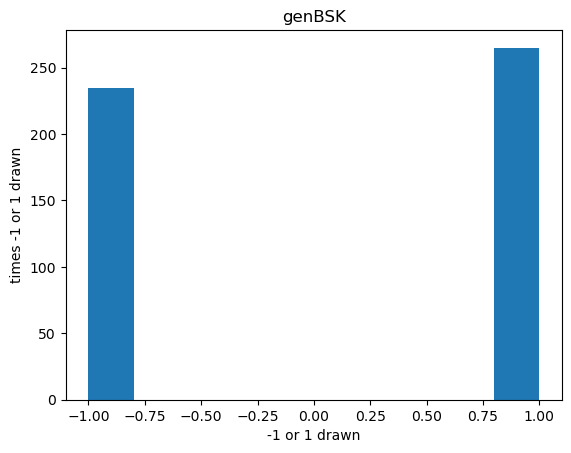

In [24]:
plt.hist(genBSK(500))
plt.title("genBSK")
plt.xlabel("-1 or 1 drawn")
plt.ylabel("times -1 or 1 drawn")
plt.show()
#By re-excecuting this cell we see that our function well randomizing between the values -1 and 1

fonction *genBruitN*

In [25]:
#Mean is null
def genNoiseN(N,Variance):
    return np.random.normal(0,np.sqrt(Variance),N)

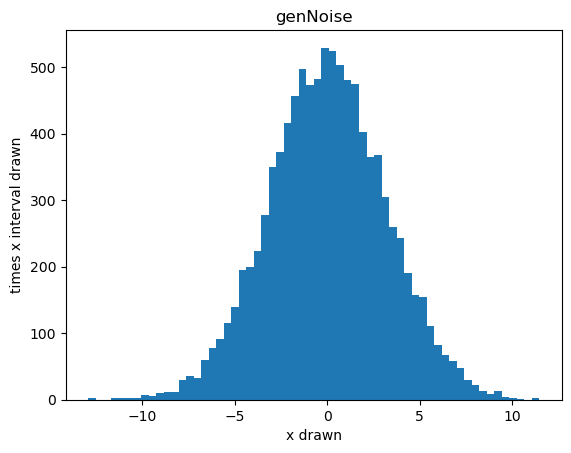

In [26]:
plt.hist(genNoiseN(10000,10),bins=60)
plt.title("genNoise")
plt.xlabel("x drawn")
plt.ylabel("times x interval drawn")
plt.show()

fonction *decodeBPSK*

In [27]:
def decodeBPSK(rn): #Because we're in a simple case (2 symbols), the only decision threshold is 0
    return np.sign(rn)
    

Simuler la chaîne de communication

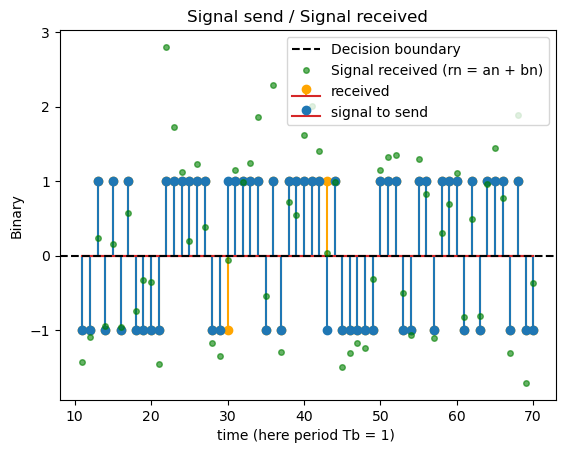

In [28]:
#Our transmitted signal is rn = an*g(0) + bn in a Nyquist channel
N=512
Variance=0.5
a=genBSK(N)
r= genNoiseN(N,Variance)+a*1
r_transmitted = decodeBPSK(r)
x=np.linspace(1,N,N)
plt.stem(x[10:70],r_transmitted[10:70],label='received',linefmt='orange', markerfmt='orange')
plt.stem(x[10:70],a[10:70],label='signal to send')
plt.axhline(0, color='black', linestyle='--', label='Decision boundary')
plt.plot(x[10:70], r[10:70], 'o', markersize=4, color='green', alpha=0.6, label='Signal received (rn = an + bn)')

#Zoomed to be clearer
plt.title("Signal send / Signal received")
plt.xlabel("time (here period Tb = 1) ")
plt.ylabel("Binary")
plt.legend()
plt.show()

Quel est le taux d’erreur binaire à la réception (par simulation) ?

In [29]:
def num_diff_arg_lists(L1,L2):
    s=0
    for i in range(len(L1)):
        if(L1[i]!=L2[i]):
            s=s+1;
    return s

def b_error_rate(a,r_transmitted,nb_iter):
    return num_diff_arg_lists(a,r_transmitted)/len(a)

def b_error_rate_with_even_more_parameters(nb_iter,N,Variance):
    Binary_error_rate=0
    for i in range(nb_iter):
        a=genBSK(N)
        r= genNoiseN(N,Variance)+a*1
        r_transmitted = decodeBPSK(r)
        Binary_error_rate=Binary_error_rate+ num_diff_arg_lists(a,r_transmitted)
    return (Binary_error_rate/(N*nb_iter))*100

In [30]:
nb_iter=100
N=10000
Variance=0.5

a=genBSK(N)
r= genNoiseN(N,Variance)+a*1
r_transmitted = decodeBPSK(r)

print("After "+str(nb_iter)+" iterations, we have a binary error rate of "
      +str(b_error_rate_with_even_more_parameters(nb_iter,N,Variance))+"%.")

After 100 iterations, we have a binary error rate of 7.877199999999999%.


**♢ Taux d’erreur binaire du canal AWGN**

Relation entre rapport signal à bruit et rapport signal à bruit normalisé : 

>Owing to the course : $\frac{g(0)^2}{\sigma_b^2}=\frac{6log_2 (M)}{M^2-1}*\frac{E_b}{N_0}$, where Eb represents the average energy per bit and N0/2 the power spectral density of the noise.
>
>Knowing that M=2 :  $2*[\frac{E_b}{N_0}]$ =  $[\frac{g(0)^2}{\sigma_b^2}]$'

Calcul de la variance du bruit $\sigma_b^2$ pour chaque valeur $[\frac{E_b}{N_0}]_{dB}$ :

In [31]:
variance_calc = lambda xdb : 1/((10**(xdb/20))*2)
for i in range(0,13,1):
    print("For "+ str(i)+"dB, we have variance ="+str(variance_calc(i)))
    
#" AND then a binary error rate of "+str(b_error_rate_with_even_more_parameters(100,512,variance_calc(i)))+"%.")

For 0dB, we have variance =0.5
For 1dB, we have variance =0.4456254690668728
For 2dB, we have variance =0.39716411736214075
For 3dB, we have variance =0.35397289219206896
For 4dB, we have variance =0.3154786722400966
For 5dB, we have variance =0.28117066259517454
For 6dB, we have variance =0.2505936168136362
For 7dB, we have variance =0.22334179607548157
For 8dB, we have variance =0.19905358527674863
For 9dB, we have variance =0.17740669461678774
For 10dB, we have variance =0.15811388300841897
For 11dB, we have variance =0.14091914656322269
For 12dB, we have variance =0.125594321575479


Tracer la courbe du taux d’erreur binaire

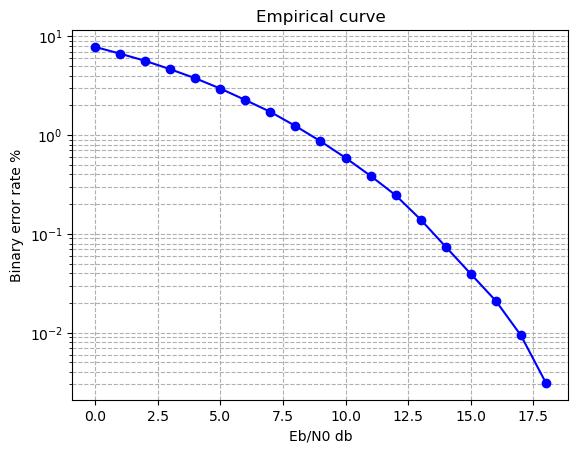

In [48]:
formula_dB = np.linspace(0,18,19)
binary_error_aftervariance = [b_error_rate_with_even_more_parameters(100,10000,variance_calc(i)) for i in range(len(formula_dB))]

#plt.plot(formula_dB, binary_error_aftervariance)
plt.semilogy(formula_dB, binary_error_aftervariance,'bo-')
plt.title("Empirical curve")
plt.xlabel("Eb/N0 db")
plt.ylabel("Binary error rate %")
plt.grid(True,which='both',linestyle='--')
plt.show()

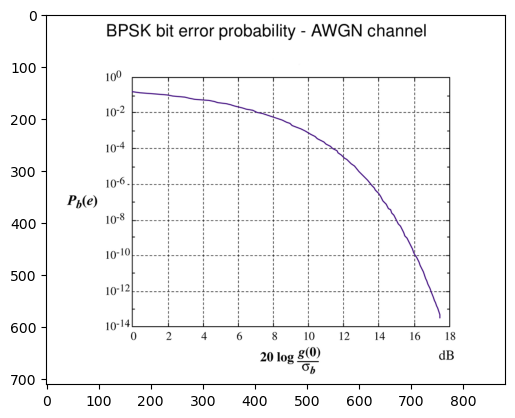

In [33]:
import matplotlib.image as mpimg
img = mpimg.imread(r"C:\Users\nicol\OneDrive\Images\Curve from the course.png") #DO NOT RE-EXCECUTE
imgplot = plt.imshow(img)
plt.show()

Commentary : the function has a behavior close to this one from the course (located slide 39). 

>We could have guessed the result because Pb(e)=Binary_error_rate/100 and $20log(\frac{g(0)}{\sigma_b})$ is proportional to $20log(\frac{E_b}{N_0})$. However at origin in these two graphs (0dB), we see that Pb(e)=Binary_error_rate/100 is not true (15% against 7%)!

La valeur de N minimale pour tracer la courbe du taux d’erreur binaire pour toute la plage de $[\frac{E_b}{N_0}]_{dB}$ :

>nb_iter * N <=> N' a signal of length nb_iter * N. For N' we have a probability sensibility of 1/N' because we count our errors. We deduce also that for high error rate the curve is less step :  $log(1-1/N')=log(N'-1)-log(N')=>$ nearly null error probability differences for high values of N' and for low error rates $log(2/N'-1/N')=-log(N')=> 10^(N')$ error probability differences.
>
>To plot for all of the interval of $[\frac{E_b}{N_0}]_{dB}$ = [0,...,12] dB, we must be able to have a Pb(e) close to $2.1*10^-3$ owing to our graph of the course and so we can take N'~477 to get as close as possible.
>If our goal is to avoid that any values is equal to zero (and so 12dB) if we repeat plenty of times its cheating (first sentence!) and we can't ensure that a plot gets any of its y-value null because of our randomiser.

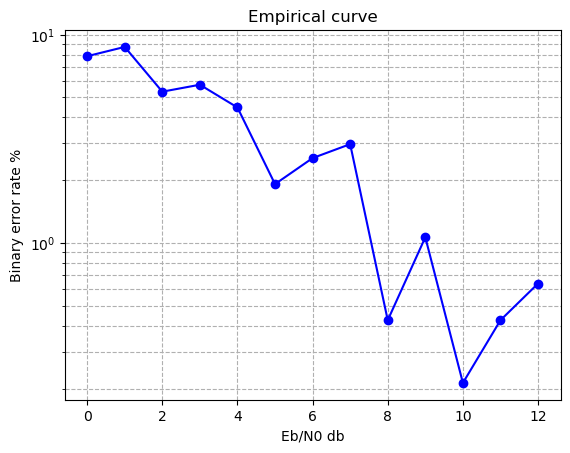

In [49]:
#Test of my theory
formula_dB = np.linspace(0,12,13)
binary_error_aftervariance = [b_error_rate_with_even_more_parameters(1,470,variance_calc(i)) for i in range(len(formula_dB))]

#plt.plot(formula_dB, binary_error_aftervariance)
plt.semilogy(formula_dB, binary_error_aftervariance,'bo-')
plt.title("Empirical curve")
plt.xlabel("Eb/N0 db")
plt.ylabel("Binary error rate %")
plt.grid(True,which='both',linestyle='--')
plt.show()

**Check point 1:** Bravo! appelez votre encadrant(e) pour valider



---



**♢ Probabilité d’erreur binaire théorique**

Tracer la courbe de la probabilité d’erreur binaire théorique. Vous pouvez utiliser la fonction *sp.erfc*

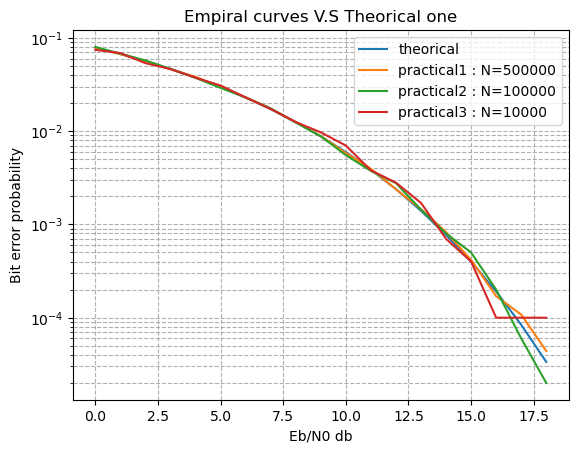

In [55]:
#mark relation between erfc(x) and Q(x)
Q = lambda x : sp.erfc(x/np.sqrt(2))/(2) #I forgot a thing in the integral
x_dB=np.linspace(0,18,19)
formula_dB = np.linspace(0,18,19)
Pb=[Q(np.sqrt(2*10**(el/20))) for el in x_dB]
plt.semilogy(x_dB,Pb,label='theorical')

binary_error_aftervariance1 = [b_error_rate_with_even_more_parameters(1,500000,variance_calc(i)) for i in range(len(formula_dB))]
plt.semilogy(formula_dB, [binary_error_aftervariance1[i]/100 for i in range(len(binary_error_aftervariance1))],label = 'practical1 : N=500000')
binary_error_aftervariance2 = [b_error_rate_with_even_more_parameters(1,100000,variance_calc(i)) for i in range(len(formula_dB))]
plt.semilogy(formula_dB, [binary_error_aftervariance2[i]/100 for i in range(len(binary_error_aftervariance2))],label = 'practical2 : N=100000')
binary_error_aftervariance3 = [b_error_rate_with_even_more_parameters(1,10000,variance_calc(i)) for i in range(len(formula_dB))]
plt.semilogy(formula_dB, [binary_error_aftervariance3[i]/100 for i in range(len(binary_error_aftervariance3))],label = 'practical3 : N=10000')

plt.title("Empiral curves V.S Theorical one")
plt.xlabel("Eb/N0 db")
#plt.ylabel("Binary error rate %")
plt.ylabel("Bit error probability")
plt.grid(True,which='both',linestyle='--')
plt.legend()
plt.show()

**♢ Comparaison des courbes d’erreur : pratique et théorique**

Comparer la courbe pratique (obtenue via simulation) avec la courbe théorique.

>Commentary : The practical plot should be on the theorical one and that's the case for values of N getting higher (the more values we have the better we have an estimation of the error). Indeed $P_S(min)$ and $P_S$ are in the mathched filter hypothesis which is the case : he is a scalar (1), hc has not been mentioned (we supposed = 1) and **hr=h*=1**.


SNR (en dB) qui permet de garantir pour une probabilité d’erreur binaire d’environ $10^{-3}$ :

**Check point 2:** Bravo! appelez votre encadrant(e) pour valider



---



# **2. Interférence entre symboles (IES) et égalisation**

In [56]:
#My partner code for function
def genNoiseN(N,Variance):
    return np.random.normal(0,np.sqrt(Variance),N)

def genBPSK(N):
    L=np.random.uniform(0,1,N)
    L=[np.sign(el-0.5) for el in L]
    return L

*fonction genSig*. Vous pouvez utiliser la fonction *lfilter*

In [57]:
from scipy.signal import lfilter

def genSig(N):
    an = genBPSK(N)
    
    # G(z) = (0.5 + 0.2z^-1) / 1
    b = [0.5, 0.2]
    a = [1]
    
    xn = lfilter(b, a, an)
    
    return an, xn

Expression de la réponse impulsionnelle du filtre global du canal $g_n$ et $x_n$:

$g_n = 0.5*δ_n + 0.2*δ[n-1]$

$g_0 = 0.5$; $g_1 = 0.2$; $g_n = 0$ for n != 0 or 1

$x_n = 0.5*a_n + 0.2*a[n-1]$

$x_0 = 0.5*a_0 + 0.2*a_(-1) = 0.5*a_0$

$x_1 = 0.5*a_1 + 0.2*a_0$

$x_2 = 0.5*a_2 + 0.2*a_1$

$x_3 = 0.5*a_3 + 0.2*a_2$

Visualiser le signal utile $x_n$

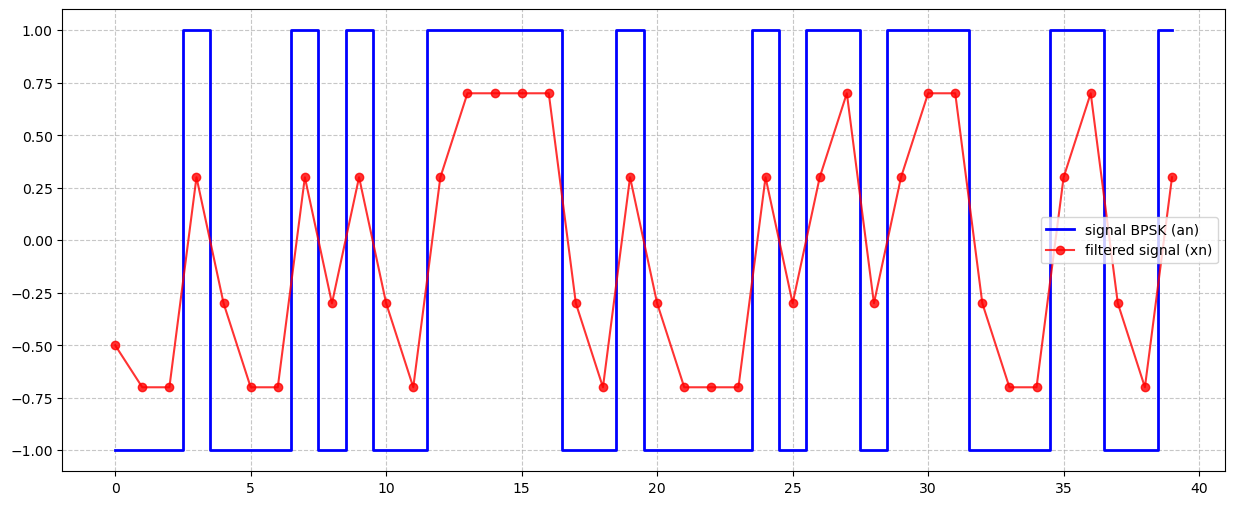

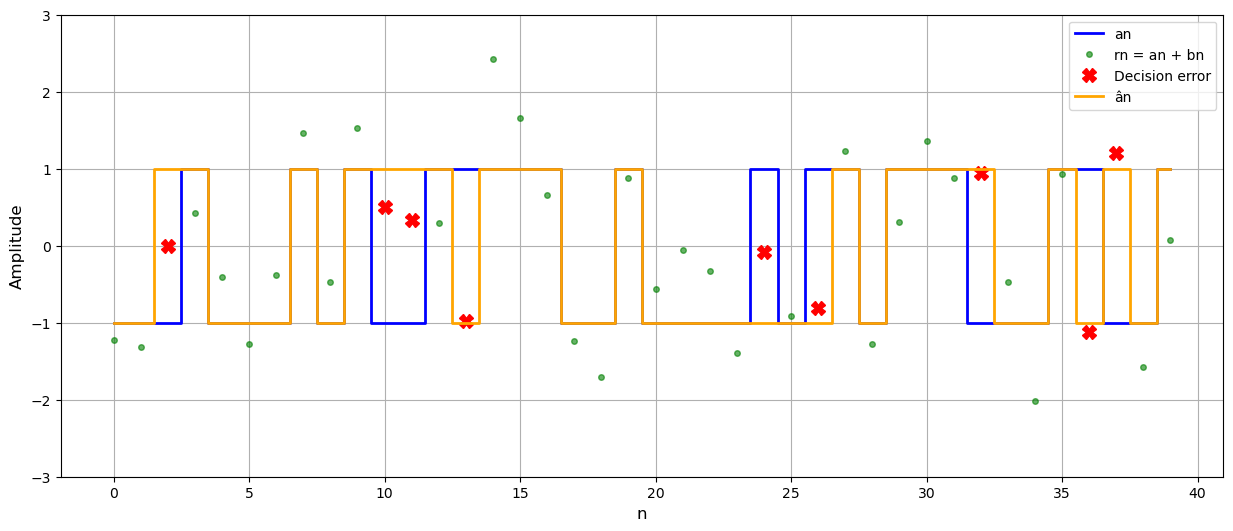


Total estimation error : 9 on 40.
TEB : 22.50%


In [58]:
N = 40

an, xn = genSig(N)

n_indices = np.arange(N)
plt.figure(figsize=(15, 6))

plt.step(n_indices, an, where='mid', label='signal BPSK (an)', color='b', linewidth=2)
plt.plot(n_indices, xn, 'o-', label='filtered signal (xn)', color='r', markersize=6, alpha=0.8)

plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

bn = genNoiseN(N, 0.5)
rn = xn + bn
estimations_an = decodeBPSK(rn)

indices = np.arange(N)
error_indices = np.where(an != estimations_an)[0]

plt.figure(figsize=(15, 6))

plt.step(indices, an, where='mid', label='an', color='blue', linewidth=2)
plt.plot(indices, rn, 'o', markersize=4, color='green', alpha=0.6, label='rn = an + bn')
plt.plot(error_indices, rn[error_indices], 'X', markersize=10, color='red', label='Decision error')
plt.step(indices, estimations_an, where='mid', label='ân', color='orange', linewidth=2)

plt.xlabel('n', fontsize=12)
plt.ylabel('Amplitude', fontsize=12)
plt.legend()
plt.grid(True)
plt.ylim(-3, 3)
plt.show()

nombre_erreurs = 0
for i in range(N):
    if an[i] != estimations_an[i]:
        nombre_erreurs += 1

print(f"\nTotal estimation error : {nombre_erreurs} on {N}.")
teb = (nombre_erreurs / N) * 100
print(f"TEB : {teb:.2f}%")

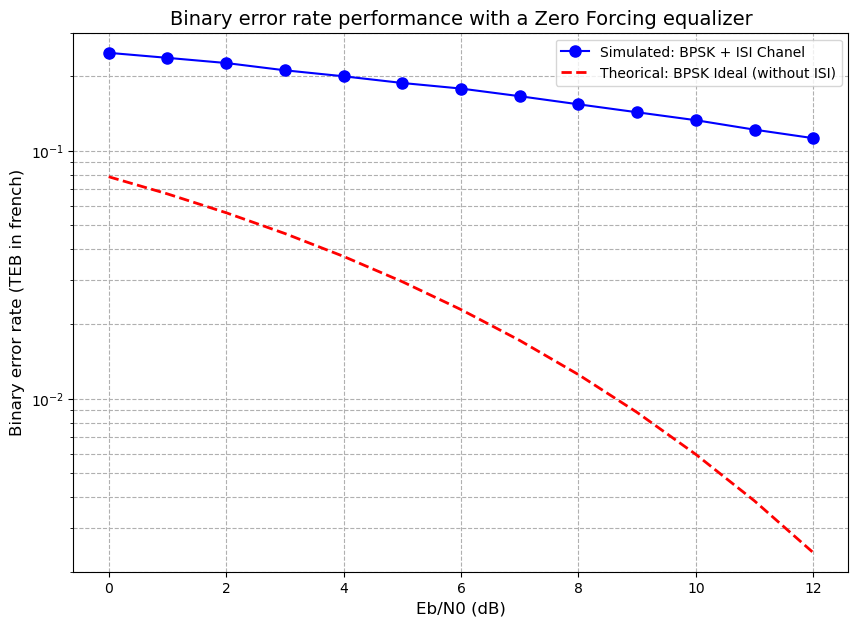

In [60]:
N = 100000

EbN0_dB_range = np.arange(0, 13)
ber_simules_zf = []

for EbN0_dB in EbN0_dB_range:
    EbN0_linear = 10**(EbN0_dB / 20.0)
    sigma2_b = 1 / (2 * EbN0_linear)
    
    an_emis = genBPSK(N)
    
    b_G = [0.5, 0.2]
    a_G = [1]
    xn = lfilter(b_G, a_G, an_emis)
    
    bruit = genNoiseN(N, sigma2_b)
    rn = xn + bruit
    
    an_decide = decodeBPSK(rn)
    
    nombre_erreurs = np.sum(an_emis != an_decide)
    teb = nombre_erreurs / N
    ber_simules_zf.append(teb)

EbN0_linear_theorique = 10**(EbN0_dB_range / 20.0)
ber_theorique_bpsk = 0.5 * sp.erfc(np.sqrt(EbN0_linear_theorique))

plt.figure(figsize=(10, 7))
plt.semilogy(EbN0_dB_range, ber_simules_zf, 'bo-', markersize=8, label='Simulated: BPSK + ISI Chanel')
plt.semilogy(EbN0_dB_range, ber_theorique_bpsk, 'r--', linewidth=2, label='Theorical: BPSK Ideal (without ISI)')

plt.title("Binary error rate performance with a Zero Forcing equalizer", fontsize=14)
plt.xlabel('Eb/N0 (dB)', fontsize=12)
plt.ylabel('Binary error rate (TEB in french)', fontsize=12)
plt.legend()
plt.grid(True, which="both", linestyle='--')
plt.ylim([2*10**-3, 0.3])
plt.show()

Commentary :

>We can see that the filtered signal xn follow the curve of the BPSK signal because we have just an delay of 1 in the filtered signal, but we have many more mistake whan decoding the signal due to the filter.
>
>Also we visibly are not in the match filter hypothesis anymore. The theorical curve acts as an probability limit now.

**Check point 3:** Bravo! appelez votre encadrant(e) pour valider

In [61]:
def egaliZF(rn):
    
    # F_ZF(z) = 1 / (0.5 + 0.2z^(-1))
    b_F = [1]
    a_F = [0.5, 0.2]
    
    tn = lfilter(b_F, a_F, rn)
    
    return tn

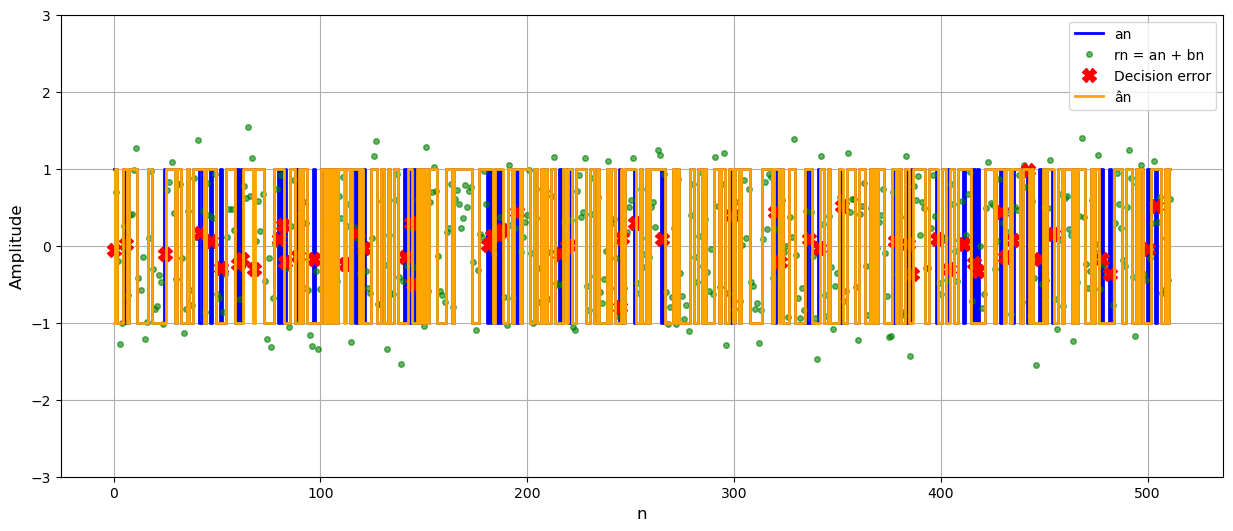

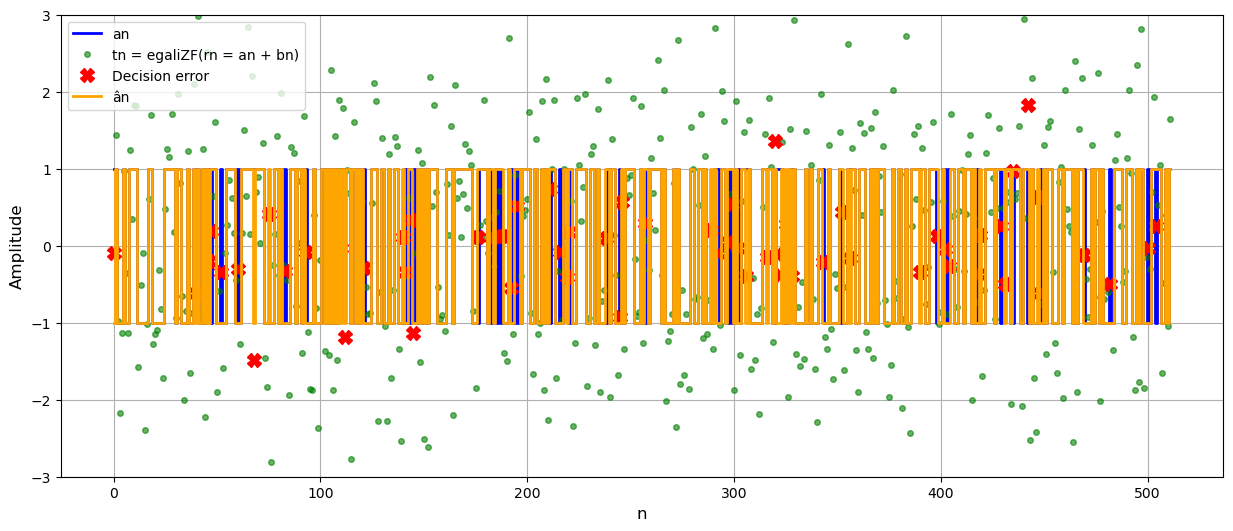


Total estimation error before ZF : 56 on 512.
TEB : 10.94%

Total estimation error : 62 on 512.
TEB : 12.11%


In [62]:
N = 512

EbN0_linear = 10**(12 / 20.0)
sigma2_b = 1 / (2 * EbN0_linear)

an, xn = genSig(N)
bn = genNoiseN(N, sigma2_b)
rn = xn + bn

estimations_an_beforeZF = decodeBPSK(rn)

indices = np.arange(N)
error_indices = np.where(an != estimations_an_beforeZF)[0]

plt.figure(figsize=(15, 6))

plt.step(indices, an, where='mid', label='an', color='blue', linewidth=2)
plt.plot(indices, rn, 'o', markersize=4, color='green', alpha=0.6, label='rn = an + bn')
plt.plot(error_indices, rn[error_indices], 'X', markersize=10, color='red', label='Decision error')
plt.step(indices, estimations_an_beforeZF, where='mid', label='ân', color='orange', linewidth=2)

plt.xlabel('n', fontsize=12)
plt.ylabel('Amplitude', fontsize=12)
plt.legend()
plt.grid(True)
plt.ylim(-3, 3)
plt.show()

tn = egaliZF(rn)
estimations_an = decodeBPSK(tn)

indices = np.arange(N)
error_indices = np.where(an != estimations_an)[0]

plt.figure(figsize=(15, 6))

plt.step(indices, an, where='mid', label='an', color='blue', linewidth=2)
plt.plot(indices, tn, 'o', markersize=4, color='green', alpha=0.6, label='tn = egaliZF(rn = an + bn)')
plt.plot(error_indices, tn[error_indices], 'X', markersize=10, color='red', label='Decision error')
plt.step(indices, estimations_an, where='mid', label='ân', color='orange', linewidth=2)

plt.xlabel('n', fontsize=12)
plt.ylabel('Amplitude', fontsize=12)
plt.legend()
plt.grid(True)
plt.ylim(-3, 3)
plt.show()

nombre_erreurs = 0
for i in range(N):
    if an[i] != estimations_an_beforeZF[i]:
        nombre_erreurs += 1

print(f"\nTotal estimation error before ZF : {nombre_erreurs} on {N}.")
teb = (nombre_erreurs / N) * 100
print(f"TEB : {teb:.2f}%")

nombre_erreurs = 0
for i in range(N):
    if an[i] != estimations_an[i]:
        nombre_erreurs += 1

print(f"\nTotal estimation error : {nombre_erreurs} on {N}.")
teb = (nombre_erreurs / N) * 100
print(f"TEB : {teb:.2f}%")


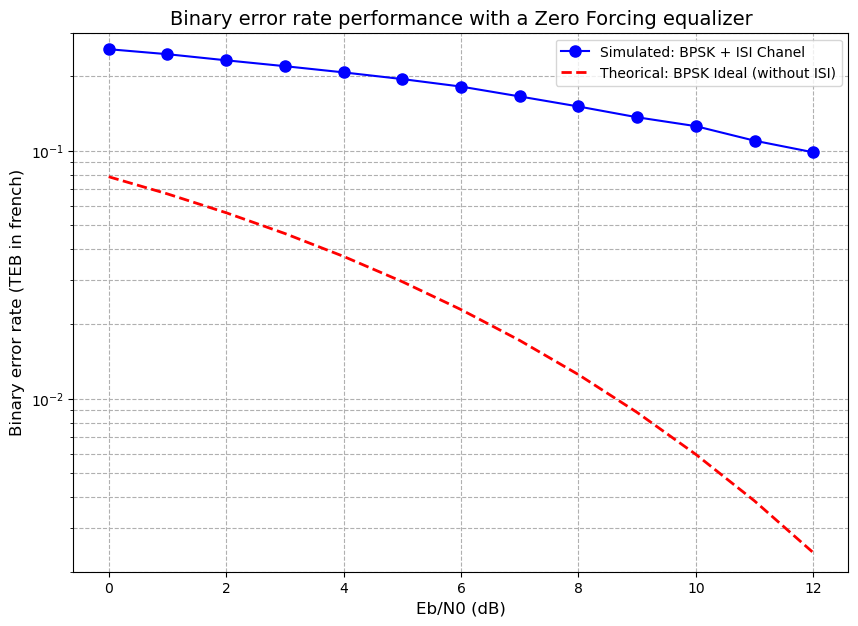

In [64]:
N = 100000

EbN0_dB_range = np.arange(0, 13)
ber_simules_zf = []

for EbN0_dB in EbN0_dB_range:
    EbN0_linear = 10**(EbN0_dB / 20.0)
    sigma2_b = 1 / (2 * EbN0_linear)
    
    an_emis = genBPSK(N)
    
    b_G = [0.5, 0.2]
    a_G = [1]
    xn = lfilter(b_G, a_G, an_emis)
    
    bruit = genNoiseN(N, sigma2_b)
    rn = xn + bruit
    
    tn = egaliZF(rn)
    
    an_decide = decodeBPSK(tn)
    
    nombre_erreurs = np.sum(an_emis != an_decide)
    teb = nombre_erreurs / N
    ber_simules_zf.append(teb)

EbN0_linear_theorique = 10**(EbN0_dB_range / 20.0)
ber_theorique_bpsk = 0.5 * sp.erfc(np.sqrt(EbN0_linear_theorique))

plt.figure(figsize=(10, 7))


plt.semilogy(EbN0_dB_range, ber_simules_zf, 'bo-', markersize=8, label='Simulated: BPSK + ISI Chanel')
plt.semilogy(EbN0_dB_range, ber_theorique_bpsk, 'r--', linewidth=2, label='Theorical: BPSK Ideal (without ISI)')

plt.title("Binary error rate performance with a Zero Forcing equalizer", fontsize=14)
plt.xlabel('Eb/N0 (dB)', fontsize=12)
plt.ylabel('Binary error rate (TEB in french)', fontsize=12)


plt.legend()
plt.grid(True, which="both", linestyle='--')
plt.ylim([2*10**-3, 0.3])
plt.show()

Commentary :

> This method make the binary error rate lower as the variance gets lower more rapidly. For high variance this method is has almost no effet. We deduce that the method is pertinent to implement if the binary error rate wished is very low because the energy gain would be way higher. (For TEB = 10^-1 we shave off ~1dB but at the beginning we have the same error rate)
> 
> This method reduce slightly the error when sigma is low. However when sigma is high, it doesn't work anymore - the error is similar as without the egalizer.